In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/davidnagib/tweets-dataset/train.csv


In [32]:
%%time

import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Concatenate, Layer
from tensorflow.keras.models import Model

CPU times: user 44 µs, sys: 5 µs, total: 49 µs
Wall time: 54.1 µs


In [33]:
%%time

data = pd.read_csv("/kaggle/input/datasets/davidnagib/tweets-dataset/train.csv")
data.head()

CPU times: user 82.5 ms, sys: 10.2 ms, total: 92.7 ms
Wall time: 96.2 ms


,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [34]:
%%time

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB
CPU times: user 14.4 ms, sys: 3.07 ms, total: 17.4 ms
Wall time: 15.8 ms


In [35]:
%%time

df = data[['text', 'sentiment']].copy()
df = df.dropna()
df.head()

CPU times: user 11.4 ms, sys: 932 µs, total: 12.4 ms
Wall time: 11 ms


,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


In [37]:
%%time

label_map = {
    'negative': 0,
    'neutral': 1,
    'positive': 2
}

df['label'] = df['sentiment'].map(label_map)

texts = df['text'].astype(str).tolist()
labels = df['label'].values

CPU times: user 5.29 ms, sys: 16 µs, total: 5.31 ms
Wall time: 5.08 ms


In [38]:
%%time

max_words = 10000
max_len = 20

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

X = tokenizer.texts_to_sequences(texts)
X = pad_sequences(X, maxlen=max_len, padding='post')

# Dummy decoder input (1 timestep)
decoder_input_data = np.zeros((len(X), 1))

# One-hot labels
y = tf.keras.utils.to_categorical(labels, num_classes=3)

# Train-validation split
X_train, X_val, dec_train, dec_val, y_train, y_val = train_test_split(
    X, decoder_input_data, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (21984, 20)
X_val shape: (5496, 20)
CPU times: user 983 ms, sys: 7.24 ms, total: 990 ms
Wall time: 990 ms


In [39]:
%%time

class BahdanauAttention(Layer):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = Dense(units)
        self.W2 = Dense(units)
        self.V = Dense(1)

    def call(self, query, values):
        # query: decoder output (batch, 1, hidden)
        # values: encoder outputs (batch, max_len, hidden)

        query_with_time_axis = tf.expand_dims(query[:, 0, :], 1)

        score = self.V(
            tf.nn.tanh(
                self.W1(values) + self.W2(query_with_time_axis)
            )
        )  # (batch, max_len, 1)

        attention_weights = tf.nn.softmax(score, axis=1)  # (batch, max_len, 1)

        context_vector = attention_weights * values
        context_vector = tf.reduce_sum(context_vector, axis=1)  # (batch, hidden)

        return context_vector, attention_weights


CPU times: user 69 µs, sys: 0 ns, total: 69 µs
Wall time: 73 µs


In [40]:
%%time

embed_dim = 128
latent_dim = 128

# Encoder
encoder_inputs = Input(shape=(max_len,), name="encoder_inputs")
enc_emb = Embedding(
    input_dim=max_words,
    output_dim=embed_dim,
    mask_zero=False,
    name="encoder_embedding"
)(encoder_inputs)

encoder_outputs, state_h, state_c = LSTM(
    latent_dim,
    return_sequences=True,
    return_state=True,
    name="encoder_lstm"
)(enc_emb)

# Decoder
decoder_inputs = Input(shape=(1,), name="decoder_inputs")
dec_emb = Embedding(
    input_dim=max_words,
    output_dim=embed_dim,
    mask_zero=False,
    name="decoder_embedding"
)(decoder_inputs)

decoder_outputs, _, _ = LSTM(
    latent_dim,
    return_sequences=True,
    return_state=True,
    name="decoder_lstm"
)(dec_emb, initial_state=[state_h, state_c])

# Attention
attention_layer = BahdanauAttention(latent_dim)
context_vector, attention_weights = attention_layer(decoder_outputs, encoder_outputs)

# Concatenate decoder + context
decoder_vector = decoder_outputs[:, 0, :]
concat = Concatenate(axis=-1)([decoder_vector, context_vector])

# Final classifier
final_output = Dense(3, activation='softmax', name="classifier")(concat)

# Model
model = Model([encoder_inputs, decoder_inputs], final_output)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 20, 128)   │  1,280,000 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 1, 128)    │  1,280,000 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 20, 128), │    131,584 │ encoder_embeddin… │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 1, 128),  │    131,584 │ decoder_embeddin… │
│                     │ (None, 128),      │            │ encoder_lstm[0][… │
│                     │ (None, 128)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 128)       │          0 │ decoder_lstm[0][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bahdanau_attention  │ [(None, 128),     │     33,153 │ decoder_lstm[0][… │
│ (BahdanauAttention) │ (None, 20, 1)]    │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 256)       │          0 │ get_item_4[0][0], │
│ (Concatenate)       │                   │            │ bahdanau_attenti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier (Dense)  │ (None, 3)         │        771 │ concatenate_7[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,857,092 (10.90 MB)

 Trainable params: 2,857,092 (10.90 MB)

 Non-trainable params: 0 (0.00 B)

CPU times: user 252 ms, sys: 16.9 ms, total: 269 ms
Wall time: 225 ms


In [41]:
%%time

history = model.fit(
    [X_train, dec_train],
    y_train,
    validation_data=([X_val, dec_val], y_val),
    epochs=5,
    batch_size=32
)

Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 34s 42ms/step - accuracy: 0.5449 - loss: 0.9207 - val_accuracy: 0.6938 - val_loss: 0.7105
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 28s 41ms/step - accuracy: 0.7619 - loss: 0.5879 - val_accuracy: 0.7045 - val_loss: 0.7008
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.8196 - loss: 0.4638 - val_accuracy: 0.7065 - val_loss: 0.7354
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 28s 41ms/step - accuracy: 0.8635 - loss: 0.3727 - val_accuracy: 0.6858 - val_loss: 0.8333
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 28s 41ms/step - accuracy: 0.8983 - loss: 0.2885 - val_accuracy: 0.6767 - val_loss: 0.9432
CPU times: user 6min 31s, sys: 34.5 s, total: 7min 6s
Wall time: 2min 27s


In [42]:
%%time

attention_model = Model(
    inputs=model.input,
    outputs=attention_weights
)

CPU times: user 2.38 ms, sys: 2.05 ms, total: 4.43 ms
Wall time: 3.56 ms


In [43]:
%%time

def plot_attention_heatmap(text):
    seq = tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_len, padding='post')

    dec_input = np.zeros((1, 1))

    # Get attention weights
    attn_scores = attention_model.predict([seq, dec_input], verbose=0)[0]  # (max_len, 1)

    tokens = text.split()[:max_len]
    attn_scores = attn_scores[:len(tokens), 0]

    plt.figure(figsize=(12, 3))
    sns.heatmap(
        attn_scores.reshape(1, -1),
        annot=True,
        cmap="viridis",
        xticklabels=tokens,
        yticklabels=["Attention"]
    )
    plt.title("Attention Heatmap")
    plt.xlabel("Input Words")
    plt.show()

CPU times: user 5 µs, sys: 1e+03 ns, total: 6 µs
Wall time: 9.3 µs


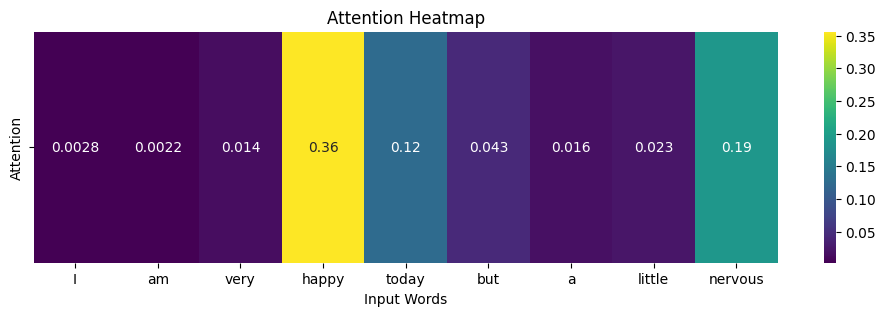

In [44]:
sample_tweet = "I am very happy today but a little nervous"
plot_attention_heatmap(sample_tweet)